In [1]:
import pandas as pd
import os
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import numpy as np
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
df_train = '/content/drive/My Drive/Colab Notebooks/TP3_DIPLO/Processed/train_topicos.csv'
df_test = '/content/drive/My Drive/Colab Notebooks/TP3_DIPLO/Processed/test_topicos.csv'

In [3]:
df_train = pd.read_csv(df_train)
df_test = pd.read_csv(df_test)

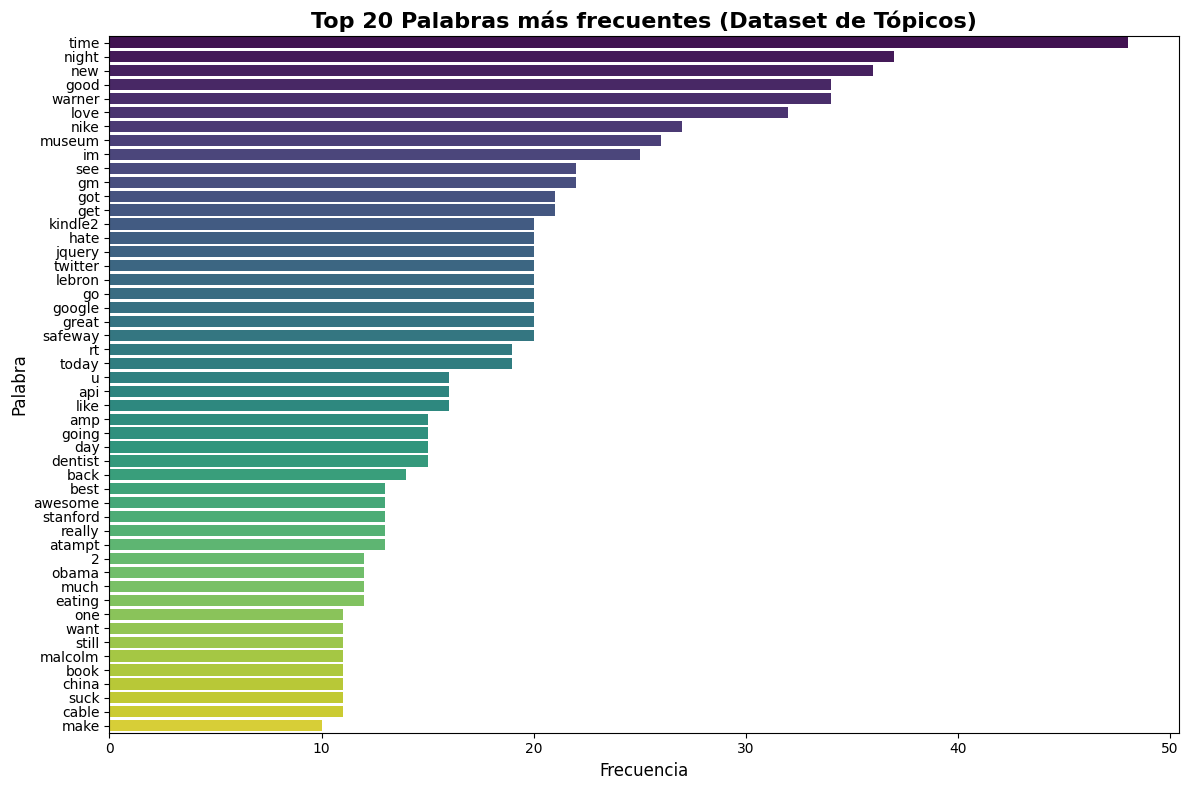

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Definimos la ruta correcta
path_test = '/content/drive/My Drive/Colab Notebooks/TP3_DIPLO/Processed/test_topicos.csv'

# Cargamos el dataset de tópicos
df_topicos = pd.read_csv(path_test)

todas_las_palabras = ' '.join(df_topicos['text_avanzado'].astype(str)).split()

# Contamos la frecuencia
conteo = Counter(todas_las_palabras)
top_20 = pd.DataFrame(conteo.most_common(50), columns=['Palabra', 'Frecuencia'])

# Graficamos
plt.figure(figsize=(12, 8))
# Se asigna hue='Palabra' y legend=False para evitar el FutureWarning de Seaborn
sns.barplot(data=top_20, x='Frecuencia', y='Palabra', palette='viridis', hue='Palabra', legend=False)
plt.title('Top 20 Palabras más frecuentes (Dataset de Tópicos)', fontsize=16, fontweight='bold')
plt.xlabel('Frecuencia', fontsize=12)
plt.ylabel('Palabra', fontsize=12)
plt.tight_layout()
plt.savefig('top_20_palabras.png')
plt.show()

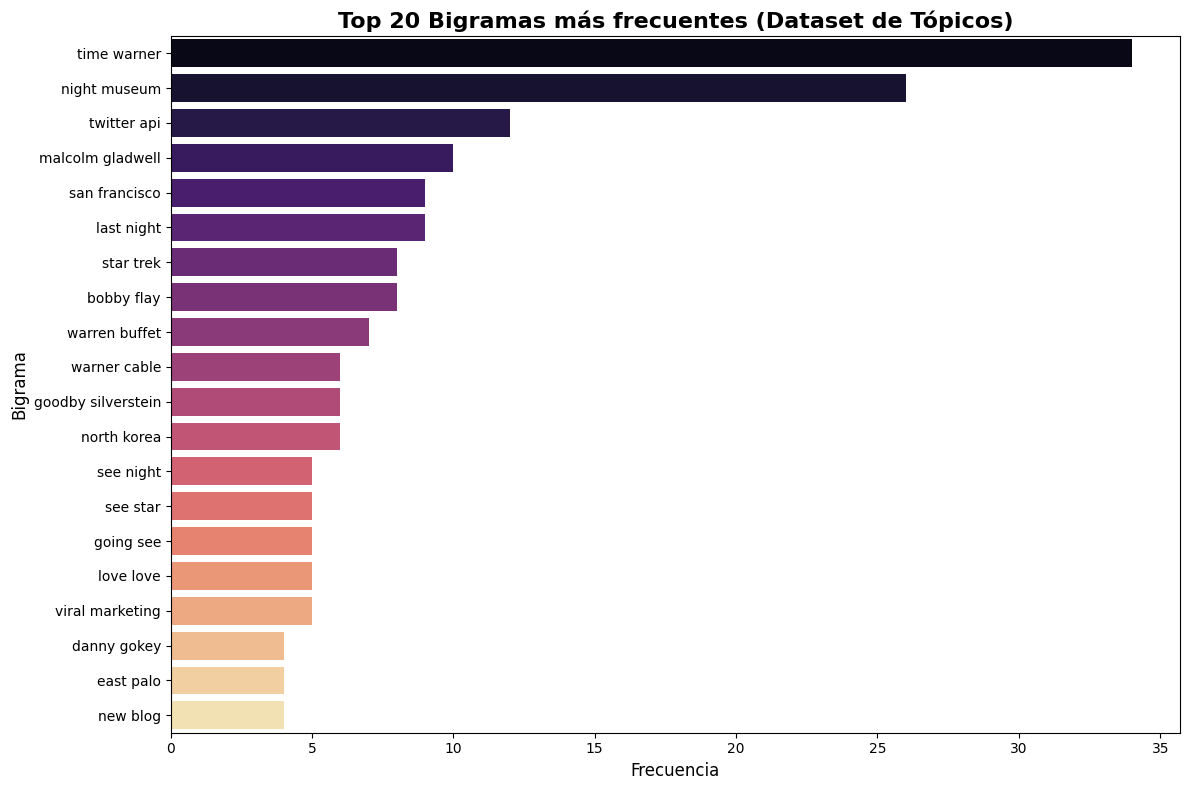

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Usamos la variable path_test que ya tiene la ruta completa al Drive
path_test = '/content/drive/My Drive/Colab Notebooks/TP3_DIPLO/Processed/test_topicos.csv'
df_topicos = pd.read_csv(path_test)

# Crear el vectorizador para obtener los 20 mejores bigramas
vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=20)
X = vectorizer.fit_transform(df_topicos['text_avanzado'].astype(str))

# Convertir a dataframe para graficar
bigram_freq = pd.DataFrame(X.sum(axis=0), columns=vectorizer.get_feature_names_out()).T
bigram_freq.columns = ['Frecuencia']
bigram_freq = bigram_freq.sort_values(by='Frecuencia', ascending=False).reset_index()

# Graficar
plt.figure(figsize=(12, 8))
# Se usa hue='index' y legend=False para compatibilidad con versiones nuevas de Seaborn
sns.barplot(data=bigram_freq, x='Frecuencia', y='index', palette='magma', hue='index', legend=False)
plt.title('Top 20 Bigramas más frecuentes (Dataset de Tópicos)', fontsize=16, fontweight='bold')
plt.xlabel('Frecuencia', fontsize=12)
plt.ylabel('Bigrama', fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# 1. Vectorizar el texto avanzado
# Usamos TF-IDF para que las palabras más raras y significativas tengan más peso
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df_topicos['text_avanzado'].astype(str))

# 2. Entrenar K-Means con 5 clústeres para una visión rápida
kmeans = KMeans(n_clusters=8, random_state=42)
kmeans.fit(X)

# 3. Mostrar las palabras clave por cada centroide
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(8):
    print(f"Clúster {i}:")
    for ind in order_centroids[i, :10]:
        print(f' %s' % terms[ind], end='')
    print()

Clúster 0:
 eating watching normal school dinner fitness hungry blog movie yema
Clúster 1:
 night museum safeway jquery dentist see good going new love
Clúster 2:
 day one best comcast life never kindle2 back get gm
Clúster 3:
 obama video dinner house speech check joke white funny make
Clúster 4:
 twitter api playing testing following hello love tweet found use
Clúster 5:
 time warner cable internet rt problem stupid ugh today hd
Clúster 6:
 lebron nike kobe new love best good factory post awesome
Clúster 7:
 really suck much iphone get guy could as still using


In [7]:
from sklearn.decomposition import LatentDirichletAllocation

# LDA funciona mejor con conteo simple, no con TF-IDF
vectorizer_lda = CountVectorizer(max_features=1000, stop_words='english')
X_lda = vectorizer_lda.fit_transform(df_topicos['text_avanzado'].astype(str))

# Probemos con solo 8 tópicos generales
lda = LatentDirichletAllocation(n_components=8, random_state=42)
lda.fit(X_lda)

# Imprimir los tópicos
terms = vectorizer_lda.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    print(f"Tópico {idx}:")
    print(" ".join([terms[i] for i in topic.argsort()[:-10:-1]]))

Tópico 0:
time warner love good got really today kindle2 video
Tópico 1:
time new gladwell malcolm warner gm rt book jquery
Tópico 2:
francisco san eating pretty kindle2 good amp using taking
Tópico 3:
hate lebron latex gm lakers hour good stanford come
Tópico 4:
night museum safeway movie got api good new google
Tópico 5:
dentist flay bobby day good fail atampt love nike
Tópico 6:
im nike korea north like home kindle2 lot lt3
Tópico 7:
jquery trek star new rt safeway twitter going gm


Se observa que el LDA fracasa en obtener una coherencia similar a los resultados del K-means, debido a que su diseño es para formatos de texto mas extensos.
Por lo encuentra dificultad para obtener un contexto en las oraciones cortas de los tweets.

In [8]:
!pip install bitermplus
import bitermplus as btm
import numpy as np
import pandas as pd

# 1. Preparación: Tokenización de los textos
texts = df_topicos['text_avanzado'].astype(str).tolist()

# Obtenemos el vocabulario y la matriz de frecuencias X
# X es una matriz CSR que es lo que BTM requiere internamente
X, vocabulary, vocab_dict = btm.get_words_freqs(texts)
documents = btm.get_vectorized_docs(texts, vocabulary)

# 2. Extracción de Biterms
biterms = btm.get_biterms(documents)

# 3. Entrenamiento
# Usamos la matriz X directamente para evitar el AttributeError del objeto list
model = btm.BTM(X, vocabulary, T=8, beta=0.01, alpha=0.01)
model.fit(biterms, iterations=20)

# 4. Extracción de tópicos y visualización
p_w_z = model.matrix_topics_words_
top_words = btm.get_top_topic_words(model, words_num=10)
print(top_words)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for bitermplus: filename=bitermplus-0.11.0-cp312-cp312-linux_x86_64.whl size=1133272 sha256=2dbfcbc108133e8520f9c3a16344a7e01cac78dd27f25241c8ba3a9c0332cb6b
  Stored in directory: /root/.cache/pip/wheels/59/50/20/1ad19ed70aff62ce7a533d36cca2813a0587602ab1098f38e4
Successfully built bitermplus


100%|██████████| 20/20 [00:00<00:00, 545.42it/s]

   topic0  topic1  topic2       topic3  topic4  topic5   topic6   topic7
0   night     get    time         love    love  warner      new  twitter
1  museum    good  warner          amp     got  google    night      api
2     see  lebron    hate          new   watch    time  kindle2     time
3    star    kobe   cable          lt3     new     car   museum      lol
4    trek   place   latex         nike   canon    hate    today     much
5    good    nike    hour         book   bobby  iphone     love       go
6     get    fail    come        danny   night   would      amp     want
7   movie    exam   great       goodby  really     got     like     make
8    food    time    suck       jquery      im   using     good      day
9   great    like      hd  silverstein   great    free     nike   lakers


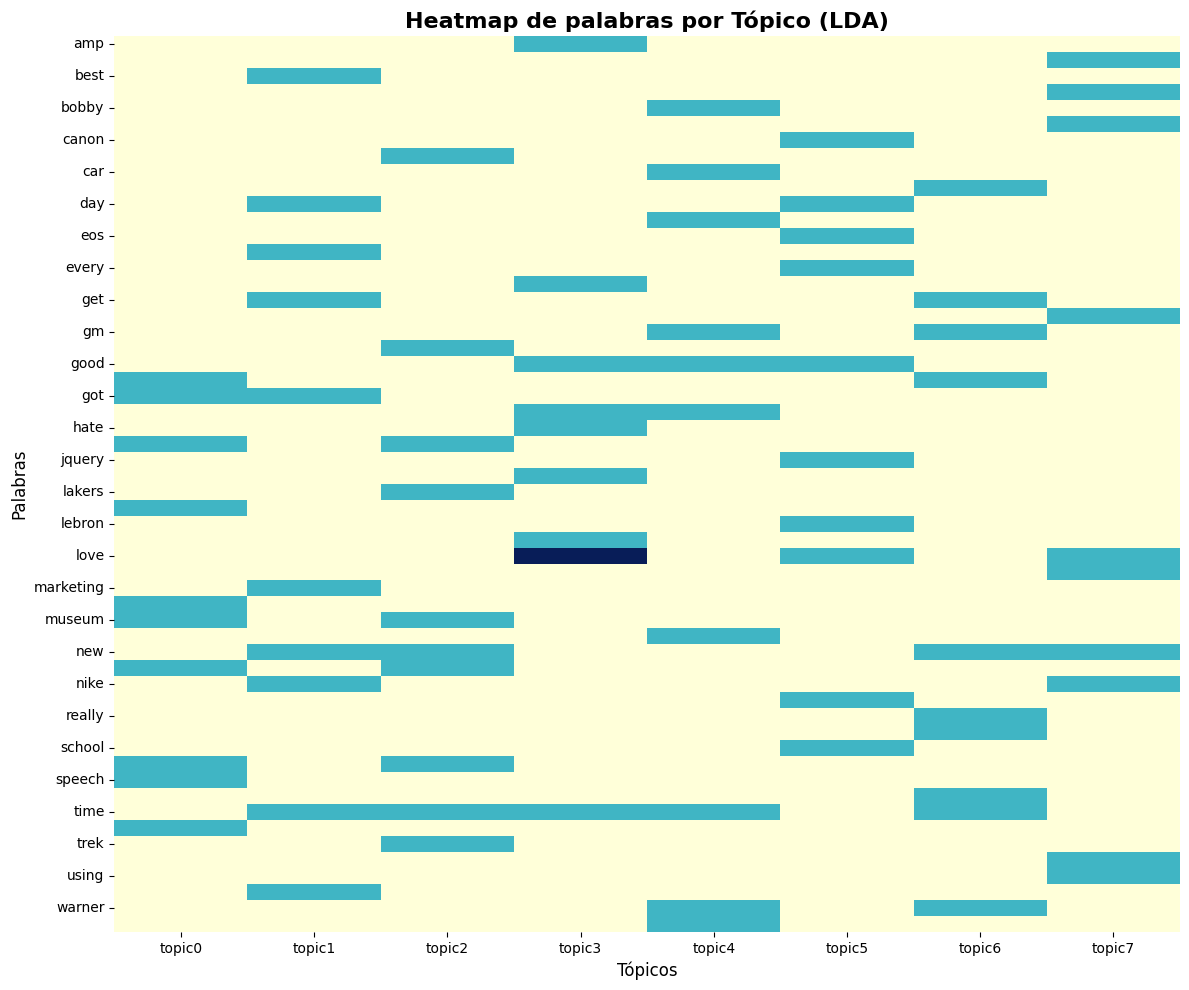

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Definimos los datos de la tabla que proporcionaste
data = {
    'topic0': ['night', 'last', 'museum', 'got', 'im', 'today', 'much', 'see', 'speech', 'google'],
    'topic1': ['best', 'marketing', 'time', 'get', 'nike', 'day', 'new', 'got', 'viral', 'ever'],
    'topic2': ['night', 'see', 'museum', 'new', 'go', 'im', 'time', 'trek', 'lakers', 'cant'],
    'topic3': ['kindle2', 'hate', 'time', 'like', 'amp', 'good', 'feel', 'great', 'love', 'love'],
    'topic4': ['time', 'warner', 'car', 'good', 'gm', 'great', 'dentist', 'wont', 'need', 'bobby'],
    'topic5': ['good', 'canon', 'jquery', 'every', 'love', 'school', 'phone', 'lebron', 'eos', 'day'],
    'topic6': ['get', 'warner', 'gm', 'stanford', 'rt', 'time', 'really', 'china', 'google', 'new'],
    'topic7': ['new', 'love', 'api', 'book', 'blog', 'using', 'nike', 'twitter', 'malcolm', 'gladwell']
}

# Creamos el DataFrame
df_topics = pd.DataFrame(data)

# Para un Heatmap, necesitamos una matriz de frecuencias o relevancia.
# Como el modelo LDA nos da palabras top, vamos a crear una matriz de "ocurrencia binaria"
# para visualizar qué palabras están presentes en qué tópico.
all_words = sorted(list(set(df_topics.values.flatten())))
heatmap_data = pd.DataFrame(0, index=all_words, columns=df_topics.columns)

for col in df_topics.columns:
    for word in df_topics[col]:
        heatmap_data.loc[word, col] += 1

# Graficar el Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, annot=False, cmap='YlGnBu', cbar=False)
plt.title('Heatmap de palabras por Tópico (LDA)', fontsize=16, fontweight='bold')
plt.xlabel('Tópicos', fontsize=12)
plt.ylabel('Palabras', fontsize=12)
plt.tight_layout()
plt.show()

Se observa la repeticion de palabras por topicos, de por ejemplo, la palabra time, se podria intentar eliminar palabras cruzadas entre topicos,pero se conservaran para evitar sesgos o forzar la eliminacion de stopwords.